# Image Captioning Bahasa Indonesia — BLIP-2 Fine-tune v2
## YOLOv11n (Object Detector) + BLIP-2 OPT-2.7B (Caption Generator)
**Platform:** Kaggle Notebook — 2x Tesla T4 GPU  
**Dataset:** Flickr8k Indonesia (8.091 gambar, 5 caption/gambar)  
**Pipeline:** Gambar → YOLO deteksi → Prompt Indonesia → BLIP-2 → Caption Indonesia

**Perubahan dari v1:**
- Prompt format: kalimat natural (`sebuah foto yang menampilkan ...`) bukan list mentah
- Unfreeze Q-Former + 2 layer terakhir OPT decoder → model belajar generate Indonesia
- Epoch: 3 → 8 dengan cosine LR schedule
- Evaluasi: BLEU-1/4 + METEOR + CIDEr per gambar

> **Wajib Save Version** sebelum session habis.

## Cell 0 — Install & Import

In [1]:
import subprocess, sys

def pip_install(*packages):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *packages], check=True)

pip_install('ultralytics')
pip_install('transformers>=4.36.0', 'accelerate>=0.26.0')
pip_install('nltk', 'pycocoevalcap', 'pycocotools')
pip_install('sentencepiece', 'protobuf')
pip_install('bitsandbytes>=0.41.0')
pip_install('peft>=0.7.0')

import os, shutil, json, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

warnings.filterwarnings('ignore')
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
N_GPU = torch.cuda.device_count()
print(f'GPU count: {N_GPU}')
for i in range(N_GPU):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name}, VRAM={props.total_memory/1e9:.1f} GB')
print('Cell 0 selesai.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00
Device: cuda
GPU count: 2
  GPU 0: Tesla T4, VRAM=15.6 GB
  GPU 1: Tesla T4, VRAM=15.6 GB
Cell 0 selesai.


## Cell 1 — Path Configuration

In [2]:
# --- Path utama ---
YOLO_WEIGHTS = Path('/kaggle/input/datasets/claudiojuniarto/yolov11n-metrics/CP2_yolov11n_full/yolov11n_best.pt')
FLICKR_ROOT  = Path('/kaggle/input/datasets/joykaihatu/image-caption-indonesia')
WORKING_DIR  = Path('/kaggle/working')
OUTPUT_DIR   = WORKING_DIR / 'outputs'
CKPT_DIR     = WORKING_DIR / 'checkpoints'
PLOT_DIR     = OUTPUT_DIR  / 'plots'

for d in [OUTPUT_DIR, CKPT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Auto-detect struktur Flickr8k ---
print('Struktur FLICKR_ROOT (40 path pertama):')
for p in sorted(FLICKR_ROOT.rglob('*'))[:40]:
    print(' ', p.relative_to(FLICKR_ROOT))

def find_dir(root, candidates):
    for name in candidates:
        p = root / name
        if p.is_dir(): return p
    dirs = [x for x in root.iterdir() if x.is_dir()]
    if dirs: return max(dirs, key=lambda d: len(list(d.glob('*.jpg'))))
    return None

def find_file(root, patterns):
    for pat in patterns:
        found = list(root.rglob(pat))
        if found: return found[0]
    return None

IMG_DIR      = find_dir(FLICKR_ROOT, ['Images', 'images', 'Flicker8k_Dataset'])
CAPTION_FILE = find_file(FLICKR_ROOT, ['captions*.txt', 'caption*.txt', '*.csv', 'Flickr8k.token.txt'])

print(f'\nIMG_DIR      : {IMG_DIR}')
print(f'CAPTION_FILE : {CAPTION_FILE}')

if IMG_DIR is None or CAPTION_FILE is None:
    raise FileNotFoundError('Folder gambar atau file caption tidak ditemukan.')

imgs = list(IMG_DIR.glob('*.jpg')) + list(IMG_DIR.glob('*.png'))
print(f'Jumlah gambar: {len(imgs)}')

# Verifikasi YOLO weight
if not YOLO_WEIGHTS.exists():
    import subprocess
    r = subprocess.run(['find', '/kaggle/input', '-name', '*.pt'],
                       capture_output=True, text=True)
    print('PT files tersedia:')
    print(r.stdout)
    raise FileNotFoundError(f'YOLO weight tidak ditemukan: {YOLO_WEIGHTS}')
print(f'YOLO weight  : OK ({YOLO_WEIGHTS})')
print('Cell 1 selesai.')

Struktur FLICKR_ROOT (40 path pertama):
  Images
  Images/1000268201_693b08cb0e.jpg
  Images/1001773457_577c3a7d70.jpg
  Images/1002674143_1b742ab4b8.jpg
  Images/1003163366_44323f5815.jpg
  Images/1007129816_e794419615.jpg
  Images/1007320043_627395c3d8.jpg
  Images/1009434119_febe49276a.jpg
  Images/1012212859_01547e3f17.jpg
  Images/1015118661_980735411b.jpg
  Images/1015584366_dfcec3c85a.jpg
  Images/101654506_8eb26cfb60.jpg
  Images/101669240_b2d3e7f17b.jpg
  Images/1016887272_03199f49c4.jpg
  Images/1019077836_6fc9b15408.jpg
  Images/1019604187_d087bf9a5f.jpg
  Images/1020651753_06077ec457.jpg
  Images/1022454332_6af2c1449a.jpg
  Images/1022454428_b6b660a67b.jpg
  Images/1022975728_75515238d8.jpg
  Images/102351840_323e3de834.jpg
  Images/1024138940_f1fefbdce1.jpg
  Images/102455176_5f8ead62d5.jpg
  Images/1026685415_0431cbf574.jpg
  Images/1028205764_7e8df9a2ea.jpg
  Images/1030985833_b0902ea560.jpg
  Images/103106960_e8a41d64f8.jpg
  Images/103195344_5d2dc613a3.jpg
  Images/103

## Cell 2 — Load Dataset & Split

Total baris caption : 40,455
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  Seorang anak berpakaian merah muda sedang mena...  
1       Seorang gadis memasuki sebuah bangunan kayu.  
2    Seorang gadis kecil naik ke rumah bermain kayu.  
3  Seorang gadis kecil menaiki tangga menuju ruma...  
4  Seorang gadis kecil berpakaian merah muda masu...  
Gambar valid (ada di disk): 8,091
Split → Train: 4500 | Val: 1000 | Test: 2591


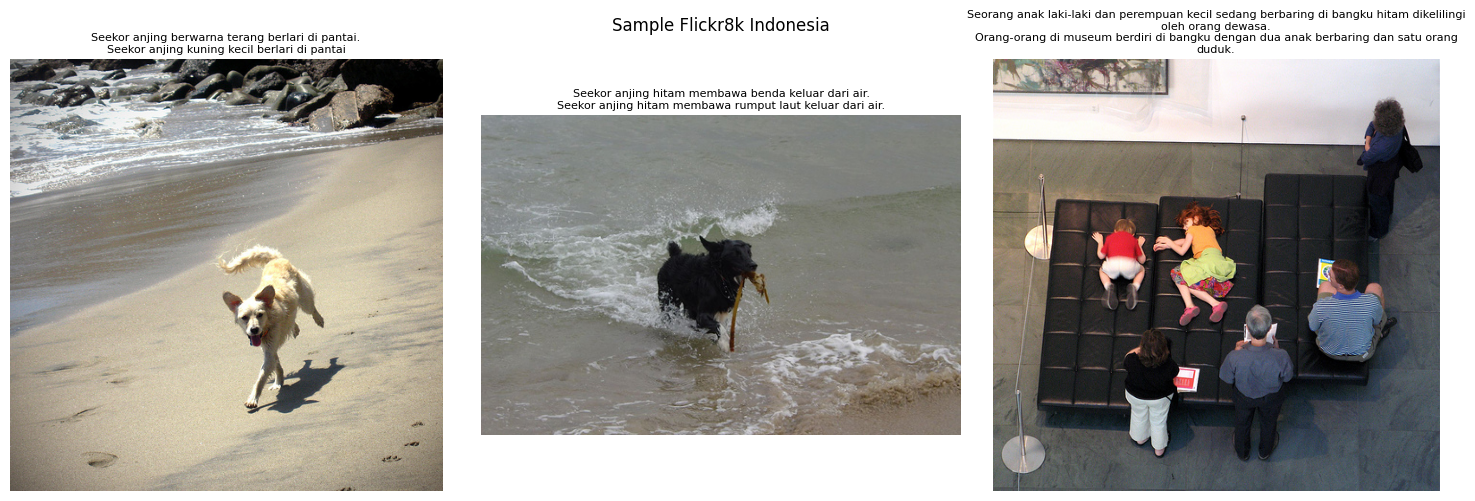

Cell 2 selesai.


In [3]:
def load_captions(caption_file):
    ext = caption_file.suffix.lower()
    if ext == '.csv':
        df = pd.read_csv(caption_file)
        img_col = next((c for c in df.columns if 'image' in c.lower() or 'file' in c.lower()), df.columns[0])
        cap_col = next((c for c in df.columns if 'caption' in c.lower() or 'text' in c.lower()), df.columns[1])
        df = df.rename(columns={img_col: 'image', cap_col: 'caption'})
    else:
        rows = []
        with open(caption_file, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 2:
                    img_id  = parts[0].split('#')[0].strip()
                    caption = parts[1].strip()
                    rows.append({'image': img_id, 'caption': caption})
        df = pd.DataFrame(rows)
    return df

df_all = load_captions(CAPTION_FILE)
print(f'Total baris caption : {len(df_all):,}')
print(df_all.head(5))

# Grup per gambar — simpan semua 5 caption sebagai reference
all_caps = df_all.groupby('image')['caption'].apply(list).reset_index()
all_caps.columns = ['image', 'captions']

existing_imgs = {p.name for p in imgs}
valid_df = all_caps[all_caps['image'].isin(existing_imgs)].reset_index(drop=True)
print(f'Gambar valid (ada di disk): {len(valid_df):,}')

# Split 6000/1000/sisa
random.seed(42)
idx = list(range(len(valid_df)))
random.shuffle(idx)
n_total = len(idx)
n_train = min(4500, int(n_total * 0.75))
n_val   = min(1000, int(n_total * 0.125))

train_df = valid_df.iloc[idx[:n_train]].reset_index(drop=True)
val_df   = valid_df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
test_df  = valid_df.iloc[idx[n_train+n_val:]].reset_index(drop=True)
print(f'Split → Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Sample visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, row in zip(axes, train_df.sample(3, random_state=1).itertuples()):
    img_path = IMG_DIR / row.image
    if img_path.exists():
        ax.imshow(Image.open(img_path))
        ax.set_title('\n'.join(row.captions[:2]), fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('Sample Flickr8k Indonesia', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_dataset.png', dpi=100)
plt.show()
print('Cell 2 selesai.')

## Cell 3 — Load YOLOv11n

In [4]:
from ultralytics import YOLO

# YOLO di GPU 1 — GPU 0 penuh untuk BLIP-2
yolo_model = YOLO(str(YOLO_WEIGHTS))
yolo_model.to('cuda:1')
print(f'YOLOv11n loaded di cuda:1')
print(f'Jumlah kelas: {len(yolo_model.names)}')

# Test 1 gambar
sample_img = IMG_DIR / train_df.iloc[0]['image']
res = yolo_model.predict(str(sample_img), conf=0.25, device='cuda:1', verbose=False)
detected = [yolo_model.names[int(c)] for c in res[0].boxes.cls.tolist()] if res[0].boxes else []
print(f'Test deteksi: {detected}')
print('Cell 3 selesai.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv11n loaded di cuda:1
Jumlah kelas: 80
Test deteksi: ['sheep', 'dog', 'sports ball']
Cell 3 selesai.


## Cell 4 — Translate Dict & Prompt Builder
**Perubahan v2:** Prompt format kalimat natural, bukan list mentah.

In [20]:
COCO_ID = {
    'person':'orang','bicycle':'sepeda','car':'mobil','motorcycle':'sepeda motor',
    'airplane':'pesawat','bus':'bus','train':'kereta api','truck':'truk','boat':'perahu',
    'traffic light':'lampu lalu lintas','fire hydrant':'hidran kebakaran',
    'stop sign':'rambu berhenti','parking meter':'meteran parkir','bench':'bangku',
    'bird':'burung','cat':'kucing','dog':'anjing','horse':'kuda','sheep':'domba',
    'cow':'sapi','elephant':'gajah','bear':'beruang','zebra':'zebra','giraffe':'jerapah',
    'backpack':'ransel','umbrella':'payung','handbag':'tas tangan','tie':'dasi',
    'suitcase':'koper','frisbee':'frisbee','skis':'ski','snowboard':'papan salju',
    'sports ball':'bola olahraga','kite':'layang-layang','baseball bat':'tongkat bisbol',
    'baseball glove':'sarung tangan bisbol','skateboard':'skateboard',
    'surfboard':'papan selancar','tennis racket':'raket tenis','bottle':'botol',
    'wine glass':'gelas anggur','cup':'cangkir','fork':'garpu','knife':'pisau',
    'spoon':'sendok','bowl':'mangkuk','banana':'pisang','apple':'apel',
    'sandwich':'roti lapis','orange':'jeruk','broccoli':'brokoli','carrot':'wortel',
    'hot dog':'sosis','pizza':'pizza','donut':'donat','cake':'kue','chair':'kursi',
    'couch':'sofa','potted plant':'tanaman pot','bed':'tempat tidur',
    'dining table':'meja makan','toilet':'toilet','tv':'televisi','laptop':'laptop',
    'mouse':'tetikus','remote':'remote','keyboard':'keyboard','cell phone':'ponsel',
    'microwave':'microwave','oven':'oven','toaster':'pemanggang roti','sink':'wastafel',
    'refrigerator':'kulkas','book':'buku','clock':'jam','vase':'vas bunga',
    'scissors':'gunting','teddy bear':'boneka beruang','hair drier':'pengering rambut',
    'toothbrush':'sikat gigi'
}

def translate_label(label_en: str) -> str:
    return COCO_ID.get(label_en.lower(), label_en)

def build_prompt_id(labels: list, max_labels: int = 6) -> str:
    """
    v2: Format kalimat natural sebagai anchor untuk OPT decoder.
    Contoh output: 'sebuah foto yang menampilkan orang, sepeda, dan anjing.'
    """
    if not labels:
        return 'sebuah foto.'
    cnt = Counter(labels)
    unique = [lbl for lbl, _ in cnt.most_common(max_labels)]
    translated = [translate_label(lbl) for lbl in unique]
    if len(translated) == 1:
        desc = translated[0]
    elif len(translated) == 2:
        desc = f'{translated[0]} dan {translated[1]}'
    else:
        desc = ', '.join(translated[:-1]) + f', dan {translated[-1]}'
    return f'sebuah foto yang menampilkan {desc}.'

def detect_and_prompt(image_path: str, conf: float = 0.25) -> tuple:
    if not Path(image_path).exists():
        return [], 'sebuah foto.'
    try:
        res = yolo_model.predict(str(image_path), conf=conf, device='cuda:1', verbose=False)
        labels = [yolo_model.names[int(c)] for c in res[0].boxes.cls.tolist()] if res[0].boxes else []
        return labels, build_prompt_id(labels)
    except Exception as e:
        print(f'YOLO error: {e}')
        return [], 'sebuah foto.'
def generate_caption(image_path: str, prompt: str = None, max_new_tokens: int = 60) -> str:
    """Generate caption dari BLIP-2 dengan atau tanpa prompt."""
    image = Image.open(image_path).convert('RGB')
    inputs = blip2_processor(
        images=image,
        text=prompt,
        return_tensors='pt'
    ).to('cuda:0', torch.float16)
    with torch.no_grad():
        out = blip2_model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=1,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=2.5,
            no_repeat_ngram_size=4,
        )
    caption = blip2_processor.decode(out[0], skip_special_tokens=True)
    if prompt and caption.lower().startswith(prompt.lower()[:20]):
        caption = caption[len(prompt):].strip(' .,')
    return caption.strip()

# Test
test_labels = ['person', 'dog', 'person', 'bicycle']
print(f'Label  : {test_labels}')
print(f'Prompt : {build_prompt_id(test_labels)}')
print('Cell 4 selesai.')

Label  : ['person', 'dog', 'person', 'bicycle']
Prompt : sebuah foto yang menampilkan orang, anjing, dan sepeda.
Cell 4 selesai.


## Cell 5 — Pre-compute YOLO Prompt Cache
Jalankan YOLO sekali untuk semua gambar train+val+test, simpan ke JSON.

In [7]:
CACHE_PATH = OUTPUT_DIR / 'prompt_cache.json'

# Load cache lama jika ada (hemat waktu re-run)
if CACHE_PATH.exists():
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        prompt_cache = json.load(f)
    print(f'Cache lama dimuat: {len(prompt_cache)} entri')
else:
    prompt_cache = {}

# Compute prompt untuk semua gambar yang belum ada di cache
all_imgs = pd.concat([train_df, val_df, test_df])['image'].unique()
missing  = [im for im in all_imgs if im not in prompt_cache]
print(f'Total gambar  : {len(all_imgs)}')
print(f'Perlu compute : {len(missing)}')

if missing:
    for img_name in tqdm(missing, desc='YOLO prompt cache'):
        img_path = IMG_DIR / img_name
        if img_path.exists():
            _, prompt = detect_and_prompt(str(img_path))
            prompt_cache[img_name] = prompt
    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(prompt_cache, f, ensure_ascii=False, indent=2)
    print(f'Cache disimpan: {len(prompt_cache)} entri → {CACHE_PATH}')
else:
    print('Semua prompt sudah ada di cache.')

# Statistik prompt
sample_prompts = list(prompt_cache.values())[:5]
print('\nSample prompts:')
for p in sample_prompts:
    print(f'  {p}')
print('Cell 5 selesai.')

Total gambar  : 8091
Perlu compute : 8091


YOLO prompt cache:   0%|          | 0/8091 [00:00<?, ?it/s]

Cache disimpan: 8091 entri → /kaggle/working/outputs/prompt_cache.json

Sample prompts:
  sebuah foto yang menampilkan domba, anjing, dan bola olahraga.
  sebuah foto yang menampilkan orang.
  sebuah foto yang menampilkan orang.
  sebuah foto yang menampilkan anjing.
  sebuah foto yang menampilkan orang.
Cell 5 selesai.


## Cell 6 — Dataset Class

In [8]:
class Flickr8kIndonesiaDataset(Dataset):
    """
    Dataset Flickr8k Indonesia untuk fine-tuning BLIP-2.
    Setiap item: pixel_values + input_ids (prompt) + labels (caption target)
    """
    def __init__(self, df, img_dir, processor, prompt_cache,
                 use_yolo_prompt=True, max_length=64):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = Path(img_dir)
        self.processor   = processor
        self.cache       = prompt_cache
        self.use_yolo    = use_yolo_prompt
        self.max_length  = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row['image']
        captions = row['captions']

        try:
            image = Image.open(self.img_dir / img_name).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))

        caption = random.choice(captions)
        prompt  = self.cache.get(img_name, 'sebuah foto.') if self.use_yolo else 'sebuah foto.'

        encoding = self.processor(
            images=image,
            text=prompt,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True
        )

        label_enc = self.processor.tokenizer(
            caption,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True
        )
        labels = label_enc['input_ids'].squeeze()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = labels
        return item

print('Dataset class siap.')
print('Cell 6 selesai.')

Dataset class siap.
Cell 6 selesai.


## Cell 7 — Load BLIP-2 & Training
**Perubahan v2:**
- Unfreeze Q-Former + 2 layer terakhir OPT decoder
- Epoch: 8, cosine LR schedule
- Gradient accumulation: 8 steps (effective batch=16)

Train: 2250 batch | Val: 500 batch


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Trainable: 105,228,800 / 3,744,761,856 (2.81%)
GPU 0: 8.1 GB free
GPU 1: 7.9 GB free
Total steps: 2810 | Warmup: 168

Mulai training: 10 epoch | effective batch=16


Epoch 1/10 [Train]:   0%|          | 0/2250 [00:00<?, ?it/s]

...

Epoch 10/10 [Train]:   0%|          | 0/2250 [00:00<?, ?it/s]

Epoch 10/10 [Val]  :   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 10: Train=4.6843 | Val=4.6759 | 7.1 jam


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

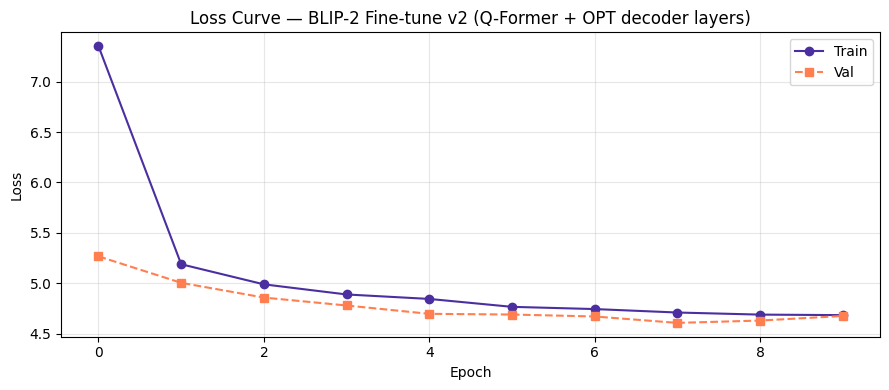


Training selesai: 7.09 jam | Best val loss: 4.6074
Cell 7 selesai.


In [13]:
import bitsandbytes as bnb
from torch.amp import autocast
from transformers import (
    Blip2Processor, Blip2ForConditionalGeneration,
    BitsAndBytesConfig, get_cosine_schedule_with_warmup
)

# --- Bersihkan GPU ---
try: del yolo_model
except: pass
try: del blip2_model
except: pass
gc.collect(); torch.cuda.empty_cache()

BLIP2_MODEL_ID  = 'Salesforce/blip2-opt-2.7b'
NUM_EPOCHS      = 10
BATCH_SIZE      = 2
GRAD_ACCUM      = 8       # effective batch = 16
LR              = 2e-5
WARMUP_RATIO    = 0.06
MAX_LENGTH      = 64
SAVE_BEST       = CKPT_DIR / 'blip2_best'
SAVE_LAST       = CKPT_DIR / 'blip2_last'

# ── Step 1: DataLoader ───────────────────────────────────────
blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL_ID, use_fast=True)

train_dataset = Flickr8kIndonesiaDataset(
    train_df, IMG_DIR, blip2_processor, prompt_cache,
    use_yolo_prompt=True, max_length=MAX_LENGTH)
val_dataset = Flickr8kIndonesiaDataset(
    val_df, IMG_DIR, blip2_processor, prompt_cache,
    use_yolo_prompt=True, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True,
                          prefetch_factor=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True,
                          prefetch_factor=2, persistent_workers=True)
print(f'Train: {len(train_loader)} batch | Val: {len(val_loader)} batch')

# ── Step 2: Load BLIP-2 8-bit ────────────────────────────────
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL_ID,
    quantization_config=BitsAndBytesConfig(load_in_8bit=True),
    device_map='balanced',
)
blip2_model.gradient_checkpointing_enable()

# ── Step 3: Unfreeze Q-Former + 2 layer terakhir OPT decoder ─
# v1 hanya unfreeze Q-Former (~2.6%) → OPT tidak belajar Indonesia
# v2 tambah 2 layer OPT decoder → model bisa generate Indonesia
for p in blip2_model.parameters():
    p.requires_grad = False

for name, p in blip2_model.named_parameters():
    if 'qformer' in name.lower() or 'query_tokens' in name.lower():
        if p.dtype in (torch.float32, torch.float16, torch.bfloat16):
            p.requires_grad = True
    # 2 layer terakhir OPT decoder
    if 'language_model.model.decoder.layers.31' in name or \
       'language_model.model.decoder.layers.30' in name:
        if p.dtype in (torch.float32, torch.float16, torch.bfloat16):
            p.requires_grad = True
    # LM head
    if 'language_model.lm_head' in name:
        if p.dtype in (torch.float32, torch.float16, torch.bfloat16):
            p.requires_grad = True

total     = sum(p.numel() for p in blip2_model.parameters())
trainable = sum(p.numel() for p in blip2_model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')
print(f'GPU 0: {torch.cuda.mem_get_info(0)[0]/1e9:.1f} GB free')
print(f'GPU 1: {torch.cuda.mem_get_info(1)[0]/1e9:.1f} GB free')

# ── Step 4: Optimizer + Cosine Scheduler ─────────────────────
trainable_params = [p for p in blip2_model.parameters() if p.requires_grad]
optimizer = bnb.optim.AdamW8bit(trainable_params, lr=LR, weight_decay=0.01)

total_steps  = NUM_EPOCHS * (len(train_loader) // GRAD_ACCUM)
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

# ── Step 5: Training Loop ─────────────────────────────────────
import time
history    = {'train_loss': [], 'val_loss': []}
best_val   = float('inf')
start_time = time.time()

print(f'\nMulai training: {NUM_EPOCHS} epoch | effective batch={BATCH_SIZE*GRAD_ACCUM}')
print('='*60)

for epoch in range(1, NUM_EPOCHS + 1):
    blip2_model.train()
    train_total = 0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]')

    for step, batch in enumerate(pbar):
        batch = {k: v.to('cuda:0') for k, v in batch.items()}
        with autocast('cuda', dtype=torch.float16):
            loss = blip2_model(**batch).loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        train_total += loss.item() * GRAD_ACCUM
        pbar.set_postfix({'loss': f'{loss.item()*GRAD_ACCUM:.4f}'})

    avg_train = train_total / len(train_loader)

    # Validation
    blip2_model.eval()
    val_total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]  '):
            batch = {k: v.to('cuda:0') for k, v in batch.items()}
            with autocast('cuda', dtype=torch.float16):
                val_total += blip2_model(**batch).loss.item()
    avg_val = val_total / len(val_loader)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    elapsed = (time.time() - start_time) / 3600
    print(f'Epoch {epoch:2d}: Train={avg_train:.4f} | Val={avg_val:.4f} | {elapsed:.1f} jam')

    # Simpan checkpoint per epoch (hapus epoch-2 untuk hemat disk)
    if epoch > 2:
        old = CKPT_DIR / f'blip2_epoch{epoch-2}'
        if old.exists(): shutil.rmtree(old)
    ckpt = CKPT_DIR / f'blip2_epoch{epoch}'
    blip2_model.save_pretrained(str(ckpt))
    blip2_processor.save_pretrained(str(ckpt))

    if avg_val < best_val:
        best_val = avg_val
        blip2_model.save_pretrained(str(SAVE_BEST))
        blip2_processor.save_pretrained(str(SAVE_BEST))
        print(f'  → Best checkpoint disimpan (val_loss={best_val:.4f})')

    gc.collect(); torch.cuda.empty_cache()

# Save last + history
blip2_model.save_pretrained(str(SAVE_LAST))
blip2_processor.save_pretrained(str(SAVE_LAST))
pd.DataFrame(history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(history['train_loss'], label='Train', marker='o', color='#4B2FA0')
plt.plot(history['val_loss'],   label='Val',   marker='s', color='coral', ls='--')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss Curve — BLIP-2 Fine-tune v2 (Q-Former + OPT decoder layers)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(PLOT_DIR / 'loss_curve.png', dpi=100)
plt.show()

total_hrs = (time.time() - start_time) / 3600
print(f'\nTraining selesai: {total_hrs:.2f} jam | Best val loss: {best_val:.4f}')
print('Cell 7 selesai.')

## Cell 8 — Load Best Model & Reload YOLO

In [23]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

# Reload YOLO untuk inference
from ultralytics import YOLO
yolo_model = YOLO(str(YOLO_WEIGHTS))
yolo_model.to('cuda:1')
print('YOLO reloaded di cuda:1')

# Load best BLIP-2
if SAVE_BEST.exists():
    print(f'Loading best model dari: {SAVE_BEST}')
    blip2_processor = Blip2Processor.from_pretrained(str(SAVE_BEST))
    blip2_model = Blip2ForConditionalGeneration.from_pretrained(
        str(SAVE_BEST),
        torch_dtype=torch.float16,
        device_map='balanced',
    )
    print('Best model loaded.')
else:
    raise FileNotFoundError('Best checkpoint tidak ada. Pastikan Cell 7 selesai.')

blip2_model.eval()

# Load prompt cache
with open(CACHE_PATH, 'r', encoding='utf-8') as f:
    prompt_cache = json.load(f)
print(f'Prompt cache: {len(prompt_cache)} entri')
print('Cell 8 selesai.')

YOLO reloaded di cuda:1
Loading best model dari: /kaggle/working/checkpoints/blip2_best


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Best model loaded.
Prompt cache: 8091 entri
Cell 8 selesai.


## Cell 9 — Evaluasi BLEU / METEOR / CIDEr
Evaluasi pada test set dengan dua kondisi: BLIP-2 + YOLO prompt vs BLIP-2 baseline (tanpa prompt).

In [24]:
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.cider.cider import Cider
import subprocess
import warnings
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

def check_java():
    try:
        subprocess.run(['java', '-version'], capture_output=True, check=True)
        return True
    except: return False

USE_METEOR = check_java()
if USE_METEOR:
    from pycocoevalcap.meteor.meteor import Meteor
    print('METEOR: pycocoevalcap (Java tersedia)')
else:
    from nltk.translate.meteor_score import meteor_score as nltk_meteor
    print('METEOR: fallback nltk')

def evaluate_set(df, img_dir, use_prompt: bool, prompt_cache: dict,
                 max_new_tokens: int = 60, label: str = ''):
    """
    Generate caption untuk seluruh df, hitung BLEU/METEOR/CIDEr.
    Return: (metrics_dict, results_list)
    """
    hyp_dict, ref_dict, results = {}, {}, []

    desc = f'Eval [{label}]'
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=desc)):
        img_name = row['image']
        img_path = Path(img_dir) / img_name
        if not img_path.exists(): continue

        img_id = str(i)
        prompt = prompt_cache.get(img_name, 'sebuah foto.') if use_prompt else None
        caption = generate_caption(str(img_path), prompt=prompt,
                                   max_new_tokens=max_new_tokens)

        hyp_dict[img_id] = [caption.lower()]
        ref_dict[img_id] = [r.lower() for r in row['captions']]
        results.append({
            'image'     : img_name,
            'caption'   : caption,
            'references': row['captions'],
            'prompt'    : prompt or '',
        })

    # BLEU 1-4
    bleu_scorer  = Bleu(4)
    bleu_scores, _ = bleu_scorer.compute_score(ref_dict, hyp_dict)

    # METEOR
    if USE_METEOR:
        meteor_scorer = Meteor()
        meteor_score, _ = meteor_scorer.compute_score(ref_dict, hyp_dict)
    else:
        scores = []
        for img_id in hyp_dict:
            refs_tok = [r.split() for r in ref_dict[img_id]]
            hyp_tok  = hyp_dict[img_id][0].split()
            scores.append(nltk_meteor(refs_tok, hyp_tok))
        meteor_score = float(np.mean(scores))

    # CIDEr
    cider_scorer = Cider()
    cider_score, cider_per_img = cider_scorer.compute_score(ref_dict, hyp_dict)

    # Per-image CIDEr
    for i, res in enumerate(results):
        res['cider'] = float(cider_per_img[i]) if i < len(cider_per_img) else 0.0

    metrics = {
        'BLEU-1'  : round(float(bleu_scores[0]), 4),
        'BLEU-4'  : round(float(bleu_scores[3]), 4),
        'METEOR'  : round(float(meteor_score),   4),
        'CIDEr'   : round(float(cider_score),    4),
    }
    return metrics, results

# Gunakan subset 200 gambar saja untuk evaluasi
test_subset = test_df.sample(200, random_state=42).reset_index(drop=True)

print('Evaluasi BLIP-2 + YOLO Prompt...')
metrics_yolo, results_yolo = evaluate_set(
    test_subset, IMG_DIR, use_prompt=True,
    prompt_cache=prompt_cache, label='YOLO+BLIP2')

print('\nEvaluasi BLIP-2 Baseline (tanpa prompt)...')
metrics_base, results_base = evaluate_set(
    test_subset, IMG_DIR, use_prompt=False,
    prompt_cache=prompt_cache, label='Baseline')

# Tabel perbandingan
rows = []
for metric in ['BLEU-1', 'BLEU-4', 'METEOR', 'CIDEr']:
    yolo_val = metrics_yolo[metric]
    base_val = metrics_base[metric]
    delta    = round(yolo_val - base_val, 4)
    rows.append({'Metric': metric,
                 'BLIP-2 + YOLO': yolo_val,
                 'BLIP-2 Baseline': base_val,
                 'Delta': delta})

df_metrics = pd.DataFrame(rows)
print('\n' + '='*55)
print(df_metrics.to_string(index=False))
print('='*55)

# Simpan CSV
df_metrics.to_csv(OUTPUT_DIR / 'evaluation_metrics.csv', index=False)
pd.DataFrame(results_yolo).to_csv(OUTPUT_DIR / 'results_with_yolo.csv', index=False)
pd.DataFrame(results_base).to_csv(OUTPUT_DIR / 'results_baseline.csv', index=False)
print('\nCSV disimpan.')
print('Cell 9 selesai.')

METEOR: pycocoevalcap (Java tersedia)
Evaluasi BLIP-2 + YOLO Prompt...


Eval [YOLO+BLIP2]:   0%|          | 0/200 [00:00<?, ?it/s]

{'testlen': 2537, 'reflen': 2273, 'guess': [2537, 2347, 2158, 1971], 'correct': [78, 0, 0, 0]}
ratio: 1.1161460624720123

Evaluasi BLIP-2 Baseline (tanpa prompt)...


Eval [Baseline]:   0%|          | 0/200 [00:00<?, ?it/s]

{'testlen': 3231, 'reflen': 2553, 'guess': [3231, 3031, 2831, 2631], 'correct': [178, 1, 0, 0]}
ratio: 1.265569917743335

Metric  BLIP-2 + YOLO  BLIP-2 Baseline   Delta
BLEU-1         0.0307           0.0551 -0.0244
BLEU-4         0.0000           0.0000  0.0000
METEOR         0.0163           0.0350 -0.0187
 CIDEr         0.0014           0.0027 -0.0013

CSV disimpan.
Cell 9 selesai.


## Cell 10 — Visualisasi Hasil

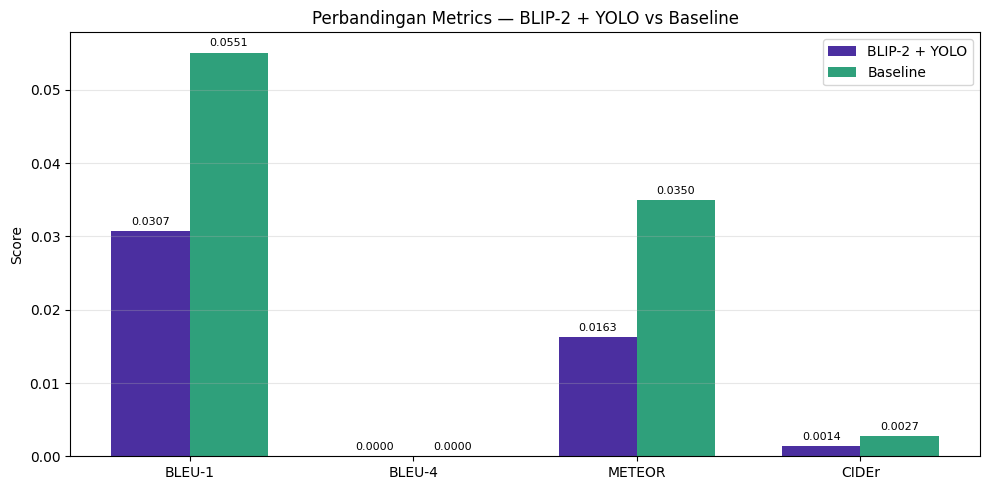

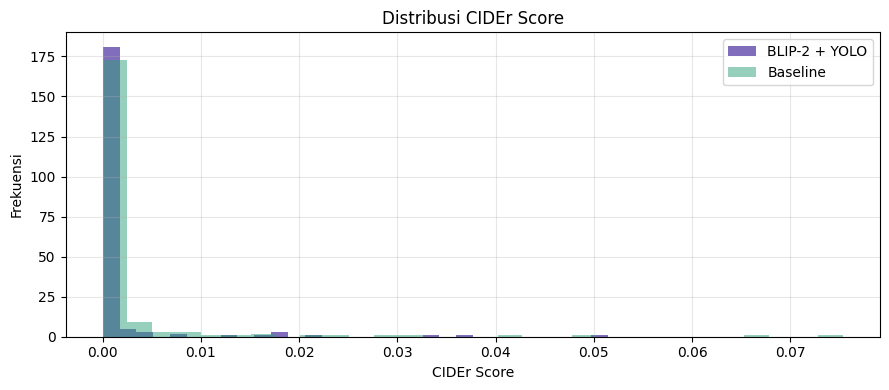

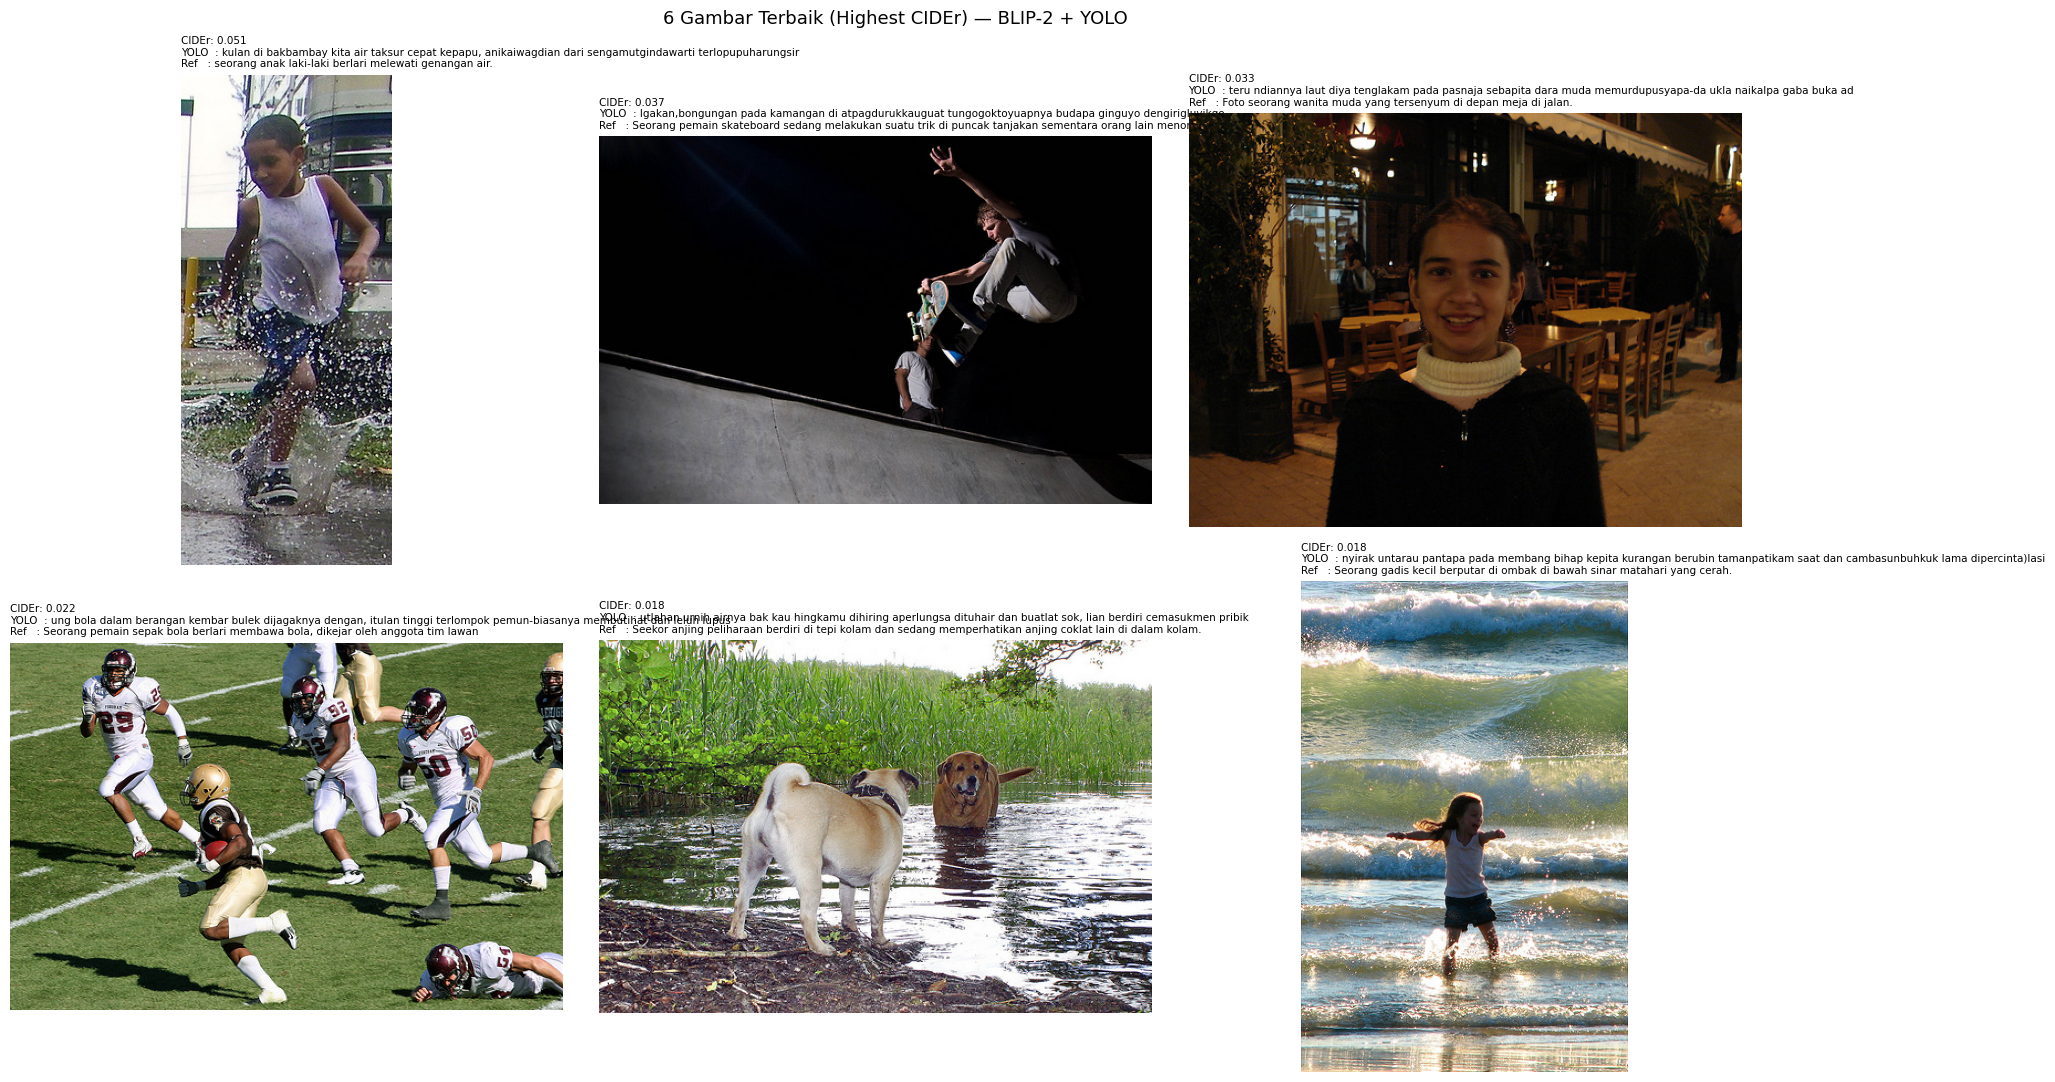

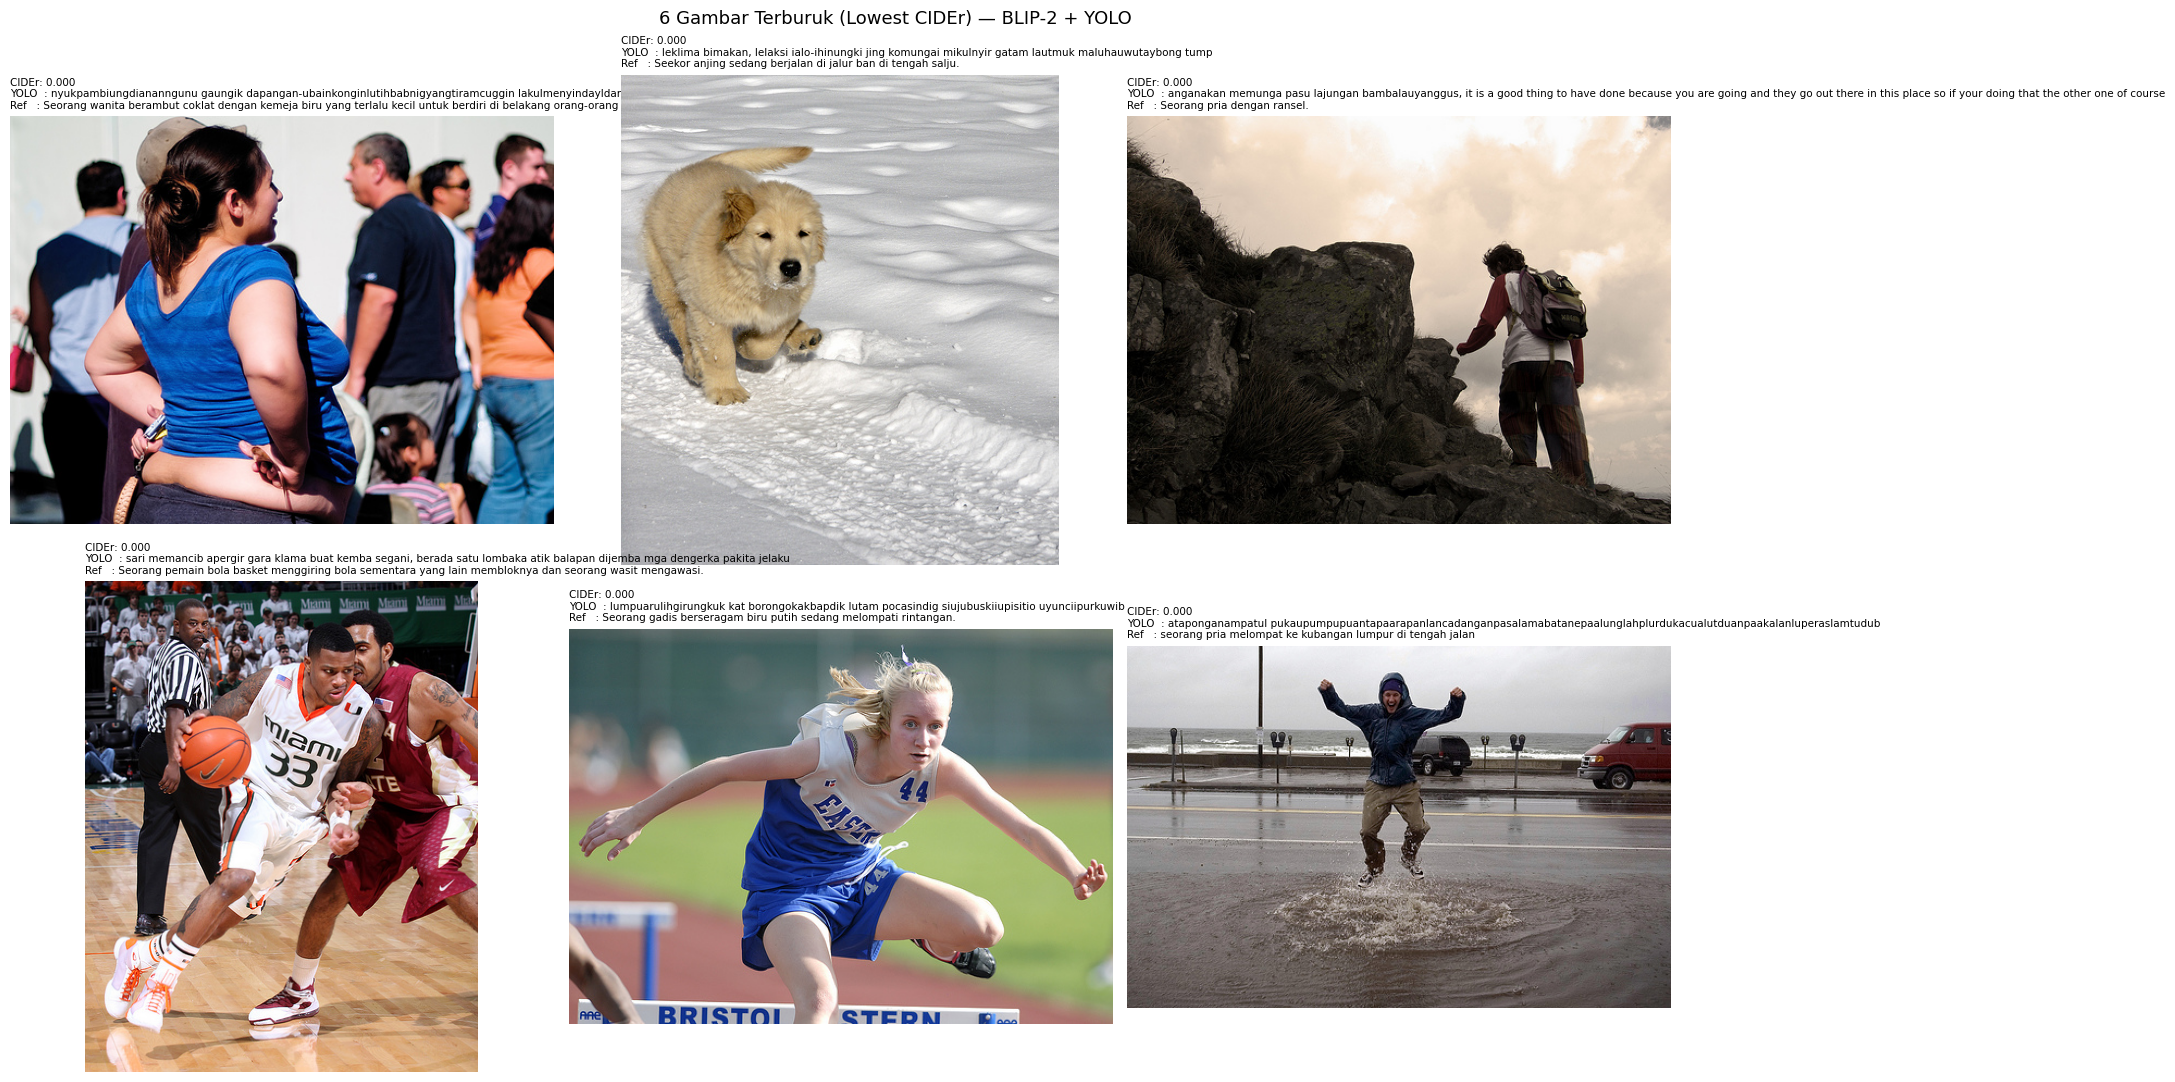

Cell 10 selesai.


In [25]:
import ast

def safe_parse_list(val):
    if isinstance(val, list): return val
    try: return ast.literal_eval(val)
    except: return [str(val)]

# 1. Bar chart metrics
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = df_metrics['Metric'].tolist()
x = np.arange(len(metrics_names))
w = 0.35
b1 = ax.bar(x - w/2, df_metrics['BLIP-2 + YOLO'],    w, label='BLIP-2 + YOLO', color='#4B2FA0')
b2 = ax.bar(x + w/2, df_metrics['BLIP-2 Baseline'],  w, label='Baseline',       color='#2FA07B')
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score'); ax.set_title('Perbandingan Metrics — BLIP-2 + YOLO vs Baseline')
ax.legend()
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'metrics_comparison.png', dpi=120)
plt.show()

# 2. CIDEr distribution
plt.figure(figsize=(9, 4))
df_y = pd.DataFrame(results_yolo)
df_b = pd.DataFrame(results_base)
plt.hist(df_y['cider'], bins=30, alpha=0.7, color='#4B2FA0', label='BLIP-2 + YOLO')
plt.hist(df_b['cider'], bins=30, alpha=0.5, color='#2FA07B', label='Baseline')
plt.xlabel('CIDEr Score'); plt.ylabel('Frekuensi')
plt.title('Distribusi CIDEr Score')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(PLOT_DIR / 'cider_distribution.png', dpi=100)
plt.show()

# 3. 6 gambar terbaik
df_best = df_y.sort_values('cider', ascending=False).head(6).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (_, row) in zip(axes.flat, df_best.iterrows()):
    img_path = IMG_DIR / row['image']
    if img_path.exists(): ax.imshow(Image.open(img_path))
    refs = safe_parse_list(row['references'])
    ax.set_title(
        f"CIDEr: {row['cider']:.3f}\n"
        f"YOLO  : {row['caption']}\n"
        f"Ref   : {refs[0]}", fontsize=7.5, loc='left')
    ax.axis('off')
plt.suptitle('6 Gambar Terbaik (Highest CIDEr) — BLIP-2 + YOLO', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_6_results.png', dpi=100)
plt.show()

# 4. 6 gambar terburuk
df_worst = df_y.sort_values('cider').head(6).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (_, row) in zip(axes.flat, df_worst.iterrows()):
    img_path = IMG_DIR / row['image']
    if img_path.exists(): ax.imshow(Image.open(img_path))
    refs = safe_parse_list(row['references'])
    ax.set_title(
        f"CIDEr: {row['cider']:.3f}\n"
        f"YOLO  : {row['caption']}\n"
        f"Ref   : {refs[0]}", fontsize=7.5, loc='left')
    ax.axis('off')
plt.suptitle('6 Gambar Terburuk (Lowest CIDEr) — BLIP-2 + YOLO', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'worst_6_results.png', dpi=100)
plt.show()

print('Cell 10 selesai.')

## Cell 11 — Save Semua Output

In [27]:
import zipfile, shutil
from IPython.display import FileLink, display

print('Menyimpan semua output...')

# Verifikasi checkpoint
for ckpt in [SAVE_BEST, SAVE_LAST]:
    if ckpt.exists():
        files = list(ckpt.iterdir())
        total_mb = sum(f.stat().st_size for f in files if f.is_file()) / 1e6
        print(f'  {ckpt.name}: {len(files)} file, {total_mb:.0f} MB')
    else:
        print(f'  {ckpt.name}: TIDAK ADA')

# Simpan prompt cache final
with open(OUTPUT_DIR / 'prompt_cache_final.json', 'w', encoding='utf-8') as f:
    json.dump(prompt_cache, f, ensure_ascii=False, indent=2)

# Zip semua CSV + plot (ringan, mudah download)
zip_path = WORKING_DIR / 'blip2_resultsv2.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in OUTPUT_DIR.rglob('*.csv'): zf.write(f, f.name)
    for f in PLOT_DIR.rglob('*.png'):   zf.write(f, f'plots/{f.name}')
    for f in OUTPUT_DIR.glob('*.json'): zf.write(f, f.name)

print(f'\nZIP results: {zip_path.stat().st_size/1e6:.1f} MB')
display(FileLink(str(zip_path)))
print('Link mati? Save Version → Output tab → blip2_results.zip')

# Ringkasan akhir
print('\n' + '='*60)
print('RINGKASAN HASIL AKHIR')
print('='*60)
for _, row in df_metrics.iterrows():
    sym = '+' if row['Delta'] >= 0 else ''
    print(f"  {row['Metric']:8s}: YOLO={row['BLIP-2 + YOLO']:.4f} | "
          f"Base={row['BLIP-2 Baseline']:.4f} | delta={sym}{row['Delta']:.4f}")
print('\nCell 11 selesai. Notebook lengkap!')

Menyimpan semua output...
  blip2_best: 6 file, 4480 MB
  blip2_last: 6 file, 4480 MB

ZIP results: 6.4 MB


/kaggle/working/blip2_resultsv2.zip

Link mati? Save Version → Output tab → blip2_results.zip

RINGKASAN HASIL AKHIR
  BLEU-1  : YOLO=0.0307 | Base=0.0551 | delta=-0.0244
  BLEU-4  : YOLO=0.0000 | Base=0.0000 | delta=+0.0000
  METEOR  : YOLO=0.0163 | Base=0.0350 | delta=-0.0187
  CIDEr   : YOLO=0.0014 | Base=0.0027 | delta=-0.0013

Cell 11 selesai. Notebook lengkap!


In [35]:
import os, subprocess, json
from pathlib import Path

KAGGLE_USERNAME = ''  # isi sendiri: kaggle.com -> Settings -> API -> Create New Token, ambil field 'username' di kaggle.json
KAGGLE_KEY = ''  # isi sendiri: dari kaggle.json yang sama, field 'key'. JANGAN commit nilainya.

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Buat metadata dulu
import json
meta = {
    "title": "blip2-best-elior",
    "id": f"{KAGGLE_USERNAME}/blip2-best-elior",
    "licenses": [{"name": "CC0-1.0"}]
}
with open('/kaggle/working/checkpoints/blip2_best/dataset-metadata.json', 'w') as f:
    json.dump(meta, f)

# Upload
r = subprocess.run([
    'kaggle', 'datasets', 'create',
    '-p', '/kaggle/working/checkpoints/blip2_best'
], capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

Starting upload for file processor_config.json
Upload successful: processor_config.json (568B)
Starting upload for file tokenizer.json
Upload successful: tokenizer.json (3MB)
Starting upload for file generation_config.json
Upload successful: generation_config.json (135B)
Starting upload for file tokenizer_config.json
Upload successful: tokenizer_config.json (369B)
Starting upload for file model.safetensors
Upload successful: model.safetensors (4GB)
Starting upload for file config.json
Upload successful: config.json (3KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/claudiojuniarto/blip2-best-elior


  0%|          | 0.00/568 [00:00<?, ?B/s]
100%|██████████| 568/568 [00:00<00:00, 1.18kB/s]

  0%|          | 0.00/3.39M [00:00<?, ?B/s]
100%|██████████| 3.39M/3.39M [00:00<00:00, 7.44MB/s]

  0%|          | 0.00/135 [00:00<?, ?B/s]
100%|██████████| 135/135 [00:00<00:00, 345B/s]

  0%|          | 0.00/369 [00:00<?, ?B/s]
100%|██████████| 369

In [31]:
import zipfile, shutil
from pathlib import Path

OUT = Path('/kaggle/working')
CKPT_DIR = OUT / 'checkpoints'

# Zip blip2_best
zip_path = OUT / 'blip2_best_model.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in (CKPT_DIR / 'blip2_best').rglob('*'):
        if f.is_file():
            zf.write(f, f.relative_to(CKPT_DIR / 'blip2_best'))

print(f'ZIP: {zip_path.stat().st_size/1e6:.0f} MB')
from IPython.display import FileLink, display
display(FileLink(str(zip_path)))
print('Link mati? Save Version → Output tab → blip2_best_model.zip')

ZIP: 3705 MB


/kaggle/working/blip2_best_model.zip

Link mati? Save Version → Output tab → blip2_best_model.zip


In [32]:
from IPython.display import HTML, display

zip_path = '/kaggle/working/blip2_best_model.zip'

display(HTML(f'''
<a href="/kaggle/working/blip2_best_model.zip" download>
    Download blip2_best_model.zip
</a>
'''))

In [33]:
# Pindah zip ke lokasi yang bisa diakses
import shutil
shutil.copy('/kaggle/working/blip2_best_model.zip', 
            '/kaggle/working/outputs/blip2_best_model.zip')
print('Copied.')

Copied.


In [29]:
import subprocess

# Cek semua file di working dir beserta ukurannya
r = subprocess.run(['du', '-sh', '/kaggle/working/*'], 
                   shell=True, capture_output=True, text=True)
print(r.stdout)

# Total
r2 = subprocess.run(['df', '-h', '/kaggle/working'], 
                    capture_output=True, text=True)
print(r2.stdout)

36	./.virtual_documents
4	./.ipynb_checkpoints
5936	./outputs/plots
7384	./outputs
4374640	./checkpoints/blip2_epoch10
4374640	./checkpoints/blip2_last
4374640	./checkpoints/blip2_epoch9
4374640	./checkpoints/blip2_best
17498564	./checkpoints
20449792	.

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   20G     0 100% /kaggle/working



In [30]:
import shutil
from pathlib import Path

CKPT_DIR = Path('/kaggle/working/checkpoints')

# Hapus semua kecuali blip2_best
for name in ['blip2_last', 'blip2_epoch9', 'blip2_epoch10']:
    p = CKPT_DIR / name
    if p.exists():
        shutil.rmtree(p)
        print(f'Deleted: {name}')

import subprocess
r = subprocess.run('du -sh /kaggle/working/*', shell=True, capture_output=True, text=True)
print(r.stdout)

Deleted: blip2_last
Deleted: blip2_epoch9
Deleted: blip2_epoch10
2.8G	/kaggle/working/blip2_best_model.zip
6.1M	/kaggle/working/blip2_results.zip
6.1M	/kaggle/working/blip2_resultsv2.zip
4.2G	/kaggle/working/checkpoints
7.3M	/kaggle/working/outputs

